In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# load data
df = pd.read_csv("Intimate Partner and Family Violence.csv")

In [6]:
# check data
df.info()
df["FAMILY_VIOLENCE_FLAG"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190723 entries, 0 to 190722
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   _id                       190723 non-null  int64 
 1   INDEX_                    190723 non-null  int64 
 2   REPORT_YEAR               190723 non-null  int64 
 3   REPORT_MONTH              190723 non-null  object
 4   REPORT_DOW                190723 non-null  object
 5   HISTORICAL                190723 non-null  object
 6   FAMILY_VIOLENCE_FLAG      190723 non-null  object
 7   FAMILY_VIOLENCE_RELATION  190723 non-null  object
 8   DIVISION                  190723 non-null  object
 9   PREMISES_TYPE             190723 non-null  object
 10  HOOD_158                  190723 non-null  object
 11  NEIGHBOURHOOD_158         190723 non-null  object
 12  HOOD_140                  190723 non-null  object
 13  NEIGHBOURHOOD_140         190723 non-null  object
 14  COUN

array(['Intimate', 'Family', 'Unclassified'], dtype=object)

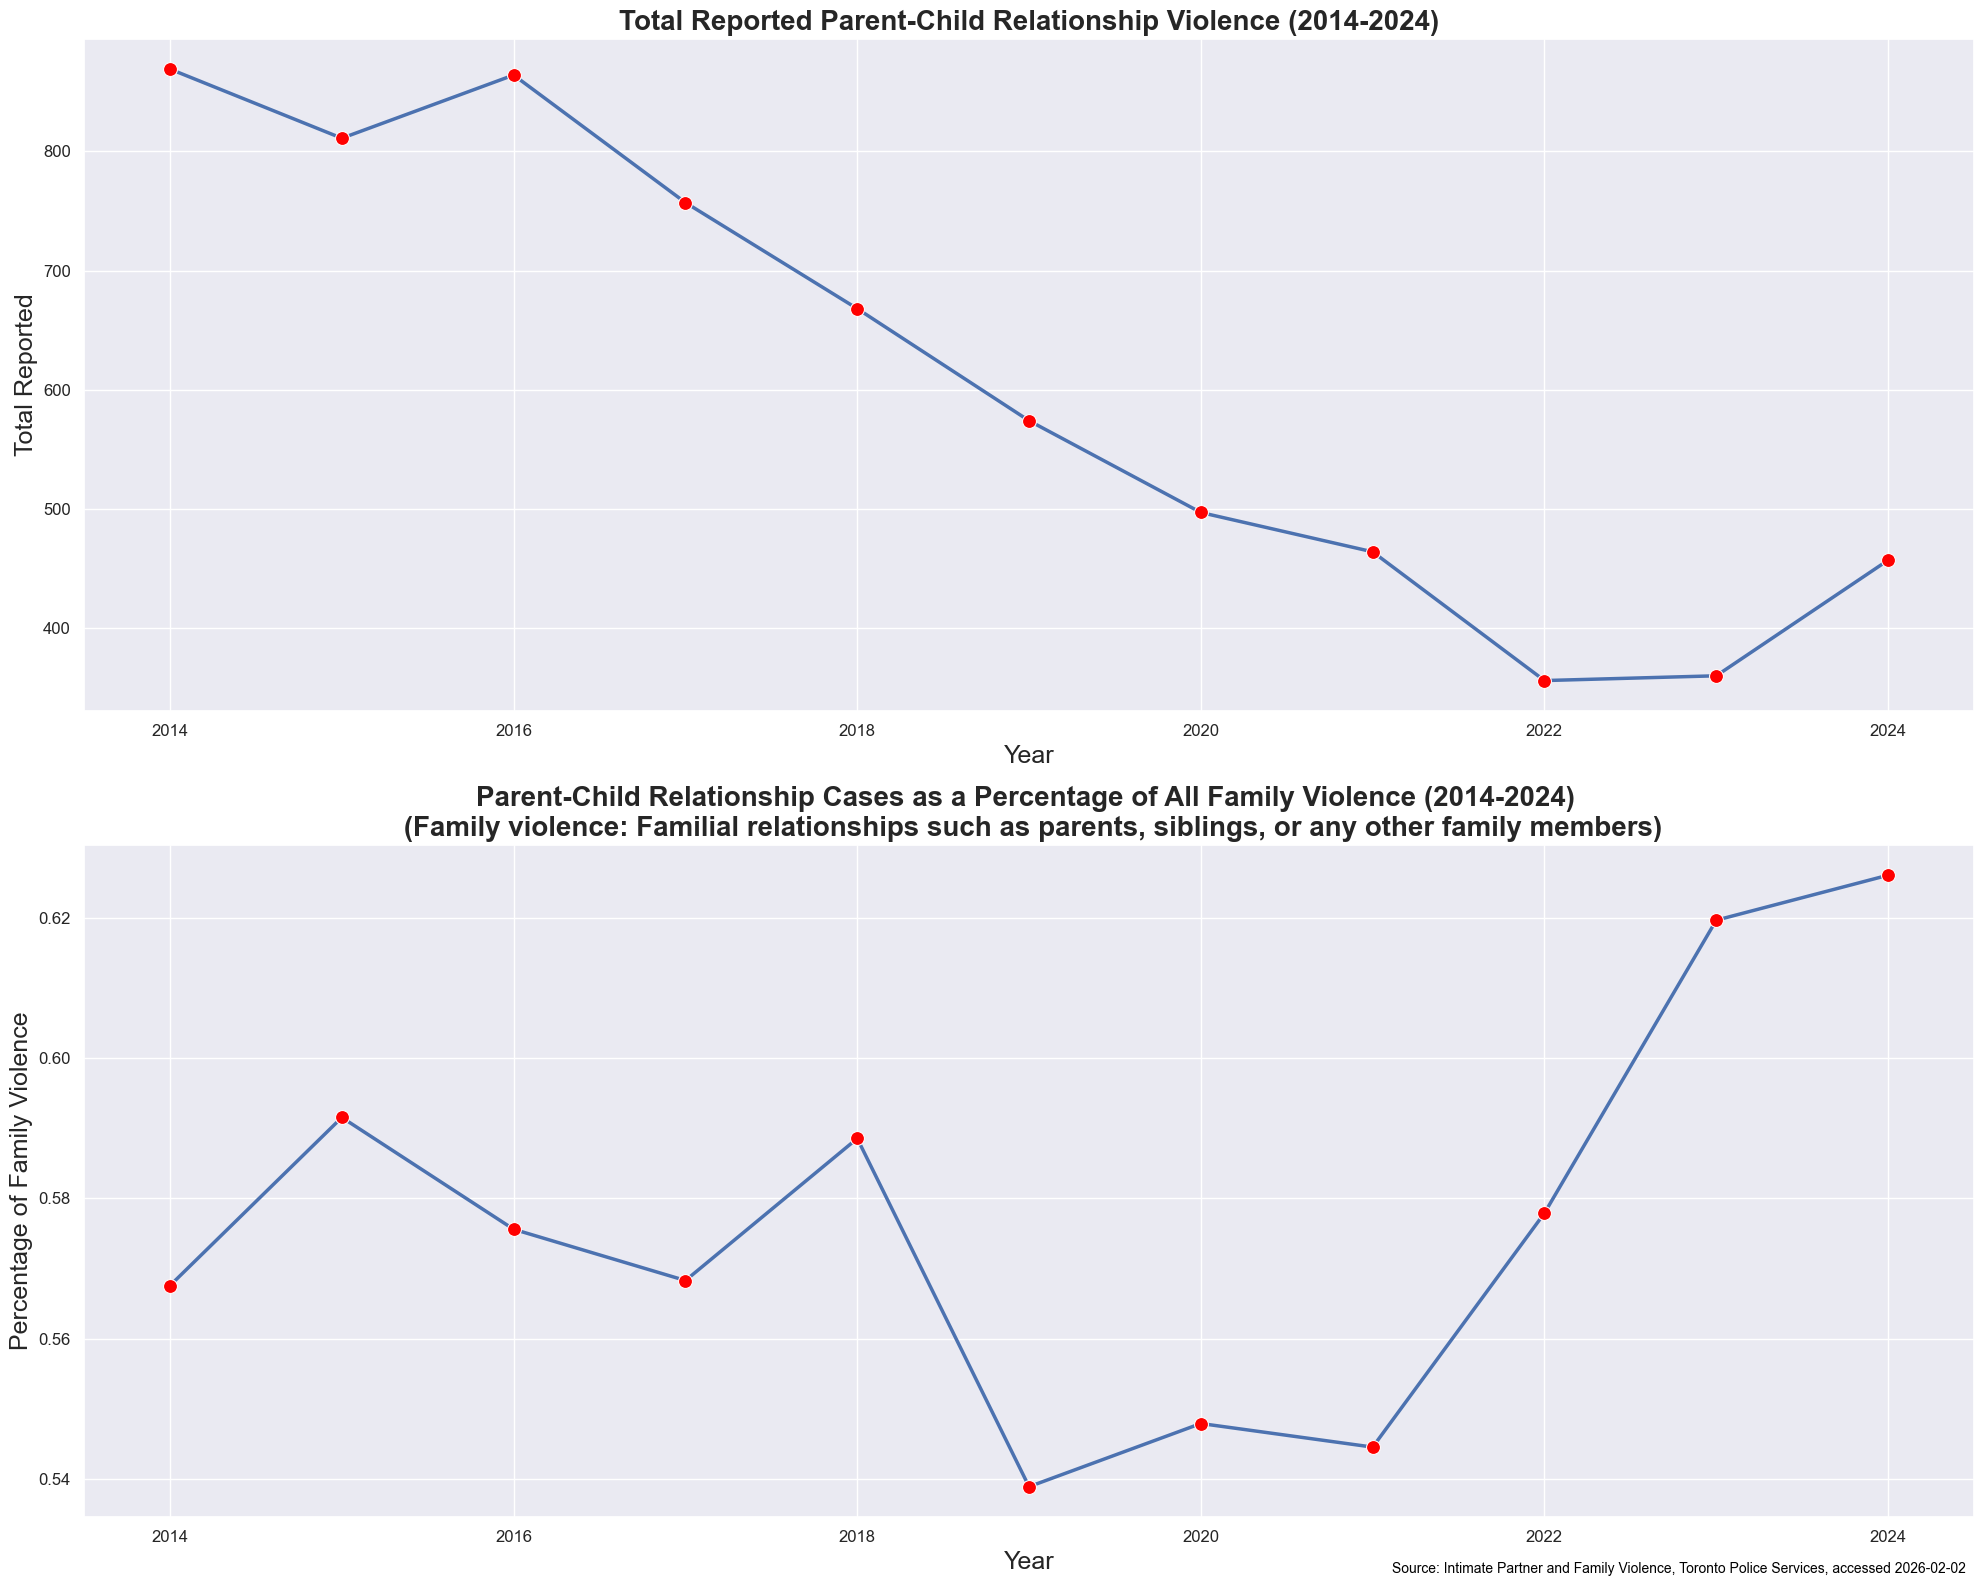

In [71]:
# Create a figure with 2 vertically stacked subplots (for absolute and relative counts)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(20, 16), facecolor="white")

# Set seaborn color palette and plotting theme for accessibility and readability
sns.set_palette("viridis")
sns.set_theme(rc={
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "ytick.labelsize": 12,
    "xtick.labelsize": 12,
})

# Group data to get total absolute count of Parent-Child Relationship violence per year
plot_df_abs = (
    df.loc[df["FAMILY_VIOLENCE_RELATION"].eq("Parent-Child Relationship")]
      .groupby("REPORT_YEAR", as_index=False)["COUNT_"]
      .sum()
)

# Calculate proportion of Parent-Child Relationship violence cases out of all Family Violence for each year
plot_df_rel = (
    df.loc[df["FAMILY_VIOLENCE_RELATION"].eq("Parent-Child Relationship")]
      .groupby("REPORT_YEAR")["COUNT_"].sum()
      .div(df.loc[df["FAMILY_VIOLENCE_FLAG"].eq("Family")]
              .groupby("REPORT_YEAR")["COUNT_"].sum())
      .reset_index(name="COUNT_")
)

# Plot the absolute counts as a lineplot in the top subplot
subplot_1 = sns.lineplot(
    data=plot_df_abs,
    x="REPORT_YEAR",
    y="COUNT_",
    marker="o",
    markerfacecolor="red",
    markersize=10,
    errorbar=None,
    linewidth=2.5,
    ax=ax[0]
)
# Set title and axis labels for the absolute count plot
subplot_1.set(
    title="Total Reported Parent-Child Relationship Violence (2014-2024)", 
    xlabel="Year", 
    ylabel="Total Reported"
)

# Plot the relative (percentage) counts as a lineplot in the bottom subplot
subplot_2 = sns.lineplot(
    data=plot_df_rel,
    x="REPORT_YEAR",
    y="COUNT_",
    marker="o",
    markerfacecolor="red",
    markersize=10,
    errorbar=None,
    linewidth=2.5,
    ax=ax[1]
)
# Set title and axis labels for the percentage plot
subplot_2.set(
    title="Parent-Child Relationship Cases as a Percentage of All Family Violence (2014-2024) \n (Family violence: Familial relationships such as parents, siblings, or any other family members)", 
    xlabel="Year", 
    ylabel="Percentage of Family Violence"
)

# Add data source text annotation beneath the plots, left-aligned, for transparency and citation
source = "Source: Intimate Partner and Family Violence, Toronto Police Services, accessed 2026-02-02"

fig.text(
    0.70, 0.01, source,   # x,y in figure coordinates (0–1)
    ha="left", va="bottom",
    fontsize=10, color="black"
)

plt.tight_layout()


Two-panel line chart showing parent–child relationship violence from 2014 to 2024. The top panel displays the total number of reported parent–child relationship violence cases by year and shows a decreasing trend. The bottom panel shows the percentage of all family violence cases involving parent–child relationships over the same period and exhibits an increasing trend.